In [1]:
# Simstack3 vs Simstack4 Flux Comparison
# Complete notebook code - copy this entire cell into Jupyter

import sys
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Any, Tuple
import glob
import warnings
warnings.filterwarnings('ignore')

from simstack4.wrapper import SimstackWrapper

sys.path.append("/Users/mviero/Repositories/simstack3")
from simstackwrapper import SimstackWrapper as SimstackWrapper3

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully!")

# ============================================================================
# CONFIGURE FILE PATHS - UPDATE THESE FOR YOUR SYSTEM
# ============================================================================

# Update these paths for your system
DATA_PATH = os.path.join(os.environ['PICKLESPATH'],'simstack','stacked_flux_densities')
SIMSTACK3_DIR = '/'.join([DATA_PATH,"cosmos2025_nuvrj_0p01_0p5_1_1p5_2_2p5_3_3p5_4_5_6_8_10p0_X_5_foregnd_atonce_"])
SIMSTACK4_FILE = '/'.join([DATA_PATH,"cosmos25_stacking_20250706_145609.json"])
#SIMSTACK4_FILE = '/'.join([DATA_PATH,"simstack3_results_converted.json"])


# Convert to Path objects and check existence
simstack3_path = Path(SIMSTACK3_DIR)
simstack4_path = Path(SIMSTACK4_FILE)

print(f"Simstack3 directory: {simstack3_path}")
print(f"  Exists: {simstack3_path.exists()}")
print(f"Simstack4 file: {simstack4_path}")
print(f"  Exists: {simstack4_path.exists()}")

Libraries imported successfully!
Simstack3 directory: /Users/mviero/data/Astronomy/pickles/simstack/stacked_flux_densities/cosmos2025_nuvrj_0p01_0p5_1_1p5_2_2p5_3_3p5_4_5_6_8_10p0_X_5_foregnd_atonce_
  Exists: True
Simstack4 file: /Users/mviero/data/Astronomy/pickles/simstack/stacked_flux_densities/cosmos25_stacking_20250706_145609.json
  Exists: True


In [2]:
path_json = os.path.join(os.environ['PICKLESPATH'],'simstack','stacked_flux_densities')
file_config = 'cosmos25.toml'

wrapper = SimstackWrapper(
    #config=f"../config/{file_config}"
)

2025-07-12 10:25:12,947 - simstack4 - INFO - SimstackWrapper initialized


In [3]:
if simstack3_path.exists():
    pickle_files = list(simstack3_path.glob("*.pkl"))
    print(f"  Found {len(pickle_files)} pickle files:")
    for pf in pickle_files[:5]:  # Show first 5
        print(f"    - {pf.name} ({pf.stat().st_size/1024/1024:.1f} MB)")
    if len(pickle_files) > 5:
        print(f"    ... and {len(pickle_files)-5} more")

# ============================================================================
# LOAD SIMSTACK3 RESULTS
# ============================================================================

def load_simstack3_results(data_dir):
    """Load and explore simstack3 results"""
    data_dir = Path(data_dir)
    
    # Find all pickle files
    pickle_files = list(data_dir.glob("*.pkl"))
    if not pickle_files:
        raise FileNotFoundError(f"No pickle files found in {data_dir}")
    
    # Load the largest file (usually contains main results)
    main_file = max(pickle_files, key=lambda f: f.stat().st_size)
    print(f"Loading main results from: {main_file.name}")
    
    with open(main_file, 'rb') as f:
        results = pickle.load(f)
    
    return results, main_file

# Load simstack3 data
if simstack3_path.exists():
    simstack3_data, ss3_file = load_simstack3_results(simstack3_path)
    
    print("\nSimstack3 data structure:")
    print(f"Type: {type(simstack3_data)}")
    
    if isinstance(simstack3_data, dict):
        print("\nTop-level keys:")
        for key in sorted(simstack3_data.keys()):
            value = simstack3_data[key]
            if hasattr(value, 'shape'):
                print(f"  {key}: {type(value).__name__} {value.shape}")
            elif hasattr(value, '__len__') and not isinstance(value, str):
                print(f"  {key}: {type(value).__name__} (length: {len(value)})")
            else:
                print(f"  {key}: {type(value).__name__}")
else:
    print("❌ Simstack3 directory not found!")
    simstack3_data = None

  Found 1 pickle files:
    - cosmos2025_nuvrj_0p01_0p5_1_1p5_2_2p5_3_3p5_4_5_6_8_10p0_X_5_foregnd_atonce_.pkl (17.9 MB)
Loading main results from: cosmos2025_nuvrj_0p01_0p5_1_1p5_2_2p5_3_3p5_4_5_6_8_10p0_X_5_foregnd_atonce_.pkl

Simstack3 data structure:
Type: <class 'simstackwrapper.SimstackWrapper'>


In [4]:
# ============================================================================
# EXPLORE SIMSTACK3 DATA STRUCTURE
# ============================================================================
if simstack3_data is not None:
    print("=== SIMSTACK3 DATA STRUCTURE EXPLORATION ===")
    print(f"Object type: {type(simstack3_data)}")
    
    # Since it's a SimstackWrapper object, check for results_dict attribute
    if hasattr(simstack3_data, 'results_dict'):
        results_dict = simstack3_data.results_dict  # Use dot notation, not dictionary access
        print(f"\nresults_dict type: {type(results_dict)}")
        
        if isinstance(results_dict, dict):
            print(f"results_dict keys: {list(results_dict.keys())}")
            
            # Check band_results_dict
            if 'band_results_dict' in results_dict:
                band_results = results_dict['band_results_dict']
                print(f"\nBand results available: {list(band_results.keys())}")
                
                # Examine first band in detail
                first_band = list(band_results.keys())[0]
                print(f"\nExamining band: {first_band}")
                band_data = band_results[first_band]
                print(f"  Keys in {first_band}: {list(band_data.keys())}")
                
                # Look at stacked_flux_densities structure
                if 'stacked_flux_densities' in band_data:
                    flux_data = band_data['stacked_flux_densities']
                    pop_labels = list(flux_data.keys())
                    print(f"\n  Population labels found: {len(pop_labels)} populations")
                    print(f"  First 5 populations:")
                    for i, pop in enumerate(pop_labels[:5]):
                        print(f"    {i}: {pop}")
                    
                    # Check what's in each population entry
                    first_pop = pop_labels[0]
                    sample_value = flux_data[first_pop]
                    print(f"\n  Sample flux value type: {type(sample_value)}")
                    print(f"  Sample flux value: {sample_value}")
                    
                    # Check if there are errors too
                    if 'stacked_flux_errors' in band_data:
                        error_data = band_data['stacked_flux_errors']
                        print(f"  Error data also available with {len(error_data)} entries")
                    else:
                        print(f"  No error data found in {first_band}")
            
            # Look for parameter labels or similar
            param_keys = [k for k in results_dict.keys() if any(word in k.lower() for word in ['param', 'label', 'pop'])]
            if param_keys:
                print(f"\nParameter/label keys found: {param_keys}")
                for key in param_keys:
                    value = results_dict[key]
                    if isinstance(value, (list, tuple)):
                        print(f"  {key}: {len(value)} entries")
                        if len(value) < 10:
                            print(f"    Content: {value}")
                        else:
                            print(f"    Sample: {value[:5]}...")
                    else:
                        print(f"  {key}: {type(value)}")
        else:
            print(f"results_dict is not a dictionary: {results_dict}")
    
    else:
        print("❌ No 'results_dict' attribute found")
        print(f"Available attributes: {[attr for attr in dir(simstack3_data) if not attr.startswith('_')]}")
        
        # Try other common attributes
        common_attrs = ['stacking_results', 'analysis_results', 'config', 'population_manager', 'flux_densities']
        for attr in common_attrs:
            if hasattr(simstack3_data, attr):
                attr_value = getattr(simstack3_data, attr)
                print(f"\nFound attribute '{attr}': {type(attr_value)}")
                
                if isinstance(attr_value, dict) and len(attr_value) < 20:
                    print(f"  Keys: {list(attr_value.keys())}")
                elif hasattr(attr_value, '__dict__'):
                    print(f"  Object attributes: {[a for a in dir(attr_value) if not a.startswith('_')][:10]}")

else:
    print("No simstack3 data to examine")

=== SIMSTACK3 DATA STRUCTURE EXPLORATION ===
Object type: <class 'simstackwrapper.SimstackWrapper'>

results_dict type: <class 'dict'>
results_dict keys: ['band_results_dict']

Band results available: ['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba_850']

Examining band: mips_24
  Keys in mips_24: ['stacked_flux_densities']

  Population labels found: 108 populations
  First 5 populations:
    0: redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0
    1: redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_1
    2: redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0
    3: redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_1
    4: redshift_0p01_0p5__stellar_mass_10p0_10p5__split_params_0

  Sample flux value type: <class 'lmfit.parameter.Parameter'>
  Sample flux value: <Parameter 'redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0', value=np.float64(8.64787490896062e-06) +/- 5.54e-07, bounds=[-inf:inf]>
  No error data found in m

In [5]:
simstack3_data.results_dict['band_results_dict'].keys()

dict_keys(['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba_850'])

In [6]:
simstack3_data.results_dict['band_results_dict']['mips_24']['stacked_flux_densities']['redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0'].value

np.float64(5.181714033619108e-05)

In [15]:
np.array([simstack3_data.results_dict['band_results_dict']['mips_24']['stacked_flux_densities'][i].value 
for i in simstack3_data.results_dict['band_results_dict']['mips_24']['stacked_flux_densities']])

array([ 8.64787491e-06,  2.36884311e-05,  5.18171403e-05,  1.77872189e-04,
        7.95501487e-05,  3.88405703e-04,  6.24081214e-05,  5.17384816e-04,
        1.23752245e-04,  3.36263054e-04,  3.22802758e-06,  5.78853563e-06,
        1.35248998e-05,  5.90873537e-05,  7.94599847e-06,  1.41770639e-04,
        2.66232196e-05,  2.22747456e-04,  2.55499787e-05,  2.54974081e-04,
        2.42305349e-07,  1.06950448e-06,  1.62620772e-05,  2.60588995e-05,
        1.35105955e-05,  6.63039667e-05,  1.26019010e-05,  1.19049882e-04,
        1.36273186e-07,  1.66825558e-04,  2.27633193e-05,  6.81930565e-07,
        3.79871071e-06,  2.74842391e-05,  9.42972437e-06,  7.11922258e-05,
        1.68296477e-05,  1.32838897e-04,  3.01525948e-06,  1.97388063e-04,
        7.50404337e-07,  1.22546230e-06,  1.46661574e-05,  2.01968961e-05,
       -1.63663561e-07,  5.78608541e-05,  1.19602420e-05,  1.08051402e-04,
       -2.36691997e-07,  1.88704778e-04, -7.86673501e-07, -3.57303831e-06,
       -2.67458780e-05,  

In [16]:
np.array([simstack3_data.results_dict['band_results_dict']['pacs_green']['stacked_flux_densities'][i].value 
for i in simstack3_data.results_dict['band_results_dict']['pacs_green']['stacked_flux_densities']])

array([ 6.54254379e-04,  4.92670705e-04,  1.08641109e-03,  3.55392173e-03,
        2.08839643e-03,  8.16729222e-03,  1.22455810e-03,  1.19928334e-02,
        1.83464748e-03,  6.34793764e-03,  1.20533109e-04,  2.11048870e-04,
        1.76489767e-04,  1.03030047e-03,  2.69857067e-04,  2.53112809e-03,
        2.50646407e-04,  3.26955965e-03, -1.63198133e-04,  3.07608602e-03,
        1.08529184e-04, -1.24042005e-04,  8.92869493e-04,  3.59705523e-04,
        4.98662241e-05,  8.74722977e-04, -1.21456205e-04,  1.45354757e-03,
        3.40634876e-04,  1.73674918e-03,  3.98116320e-04, -7.51167925e-05,
        1.36606637e-04,  3.52800599e-04, -4.00265687e-05,  7.68549777e-04,
        3.83306964e-04,  1.30992258e-03,  2.23539666e-04,  1.84670240e-03,
       -3.00911237e-04, -1.17871340e-04,  9.36101285e-04,  1.17737998e-04,
       -3.60886047e-04,  5.15855100e-04,  6.71516114e-04,  1.08295329e-03,
        2.25703758e-04,  3.33193566e-03, -1.46646918e-03, -1.82820327e-04,
       -2.14848068e-05, -

In [17]:
np.array([simstack3_data.results_dict['band_results_dict']['pacs_red']['stacked_flux_densities'][i].value 
for i in simstack3_data.results_dict['band_results_dict']['pacs_red']['stacked_flux_densities']])

array([ 3.22266593e-03,  1.89321391e-04,  2.18789484e-03,  3.85425804e-03,
        5.12574756e-03,  1.12609594e-02,  3.16271967e-03,  1.95973637e-02,
        3.21484694e-03,  9.01519435e-03,  9.96328034e-04,  1.27268328e-03,
        6.94917219e-04,  2.39902722e-03,  1.22632910e-03,  5.82269486e-03,
       -3.43807767e-04,  7.29638968e-03, -1.43676315e-03,  3.93844027e-03,
        1.27040385e-03, -1.31897533e-03,  1.62114177e-03, -4.53328678e-04,
        1.38499730e-03,  8.10313933e-04, -1.42405665e-03, -2.01131701e-05,
       -3.21051136e-04,  3.89729957e-03,  3.29639393e-04, -6.76829032e-04,
        1.62124337e-03,  2.16759580e-04,  6.11347113e-04,  1.76620762e-03,
        2.54074389e-03,  3.69028661e-03,  6.42609198e-04,  4.80820400e-03,
       -2.22308506e-03, -1.06408323e-03, -7.11395939e-03,  3.44372644e-04,
       -2.01542173e-03,  1.34921925e-03,  3.84019642e-03,  4.29584998e-03,
       -2.44132046e-03,  1.04913016e-02, -2.01928581e-02, -1.58691637e-03,
        2.39891436e-05, -

In [18]:
np.array([simstack3_data.results_dict['band_results_dict']['spire_psw']['stacked_flux_densities'][i].value 
for i in simstack3_data.results_dict['band_results_dict']['spire_psw']['stacked_flux_densities']])

array([-3.67450660e-04,  2.75266010e-04,  9.21064237e-04,  3.79059343e-03,
        9.43434659e-04,  1.00901649e-02,  5.81492904e-04,  1.70353623e-02,
        2.67236358e-03,  1.43447110e-02, -2.63193942e-04, -1.35275053e-04,
       -3.52413941e-04,  2.00579362e-03, -2.76423483e-04,  4.76777690e-03,
        4.56879113e-04,  7.99844169e-03, -5.75577461e-04,  9.99342300e-03,
        4.24336024e-04, -2.88039055e-04,  5.22504221e-04,  1.19079065e-03,
        3.84115982e-04,  2.80242945e-03,  3.75549237e-04,  5.89461774e-03,
       -8.19843327e-04,  1.08690603e-02,  3.39720282e-04, -2.98390809e-04,
       -6.05448748e-04,  8.75681896e-04, -4.83799968e-04,  2.62672132e-03,
        3.10354306e-04,  5.12145659e-03,  4.28207073e-04,  8.42207790e-03,
        7.89085580e-04, -9.81289881e-05,  1.91743089e-03,  4.08766186e-04,
       -3.97036187e-05,  1.94917888e-03,  1.11265861e-03,  4.35129358e-03,
       -1.55268131e-03,  1.00744371e-02,  1.70852777e-03, -6.46106898e-04,
       -1.70352732e-03,  

In [19]:
np.array([simstack3_data.results_dict['band_results_dict']['spire_pmw']['stacked_flux_densities'][i].value 
for i in simstack3_data.results_dict['band_results_dict']['spire_pmw']['stacked_flux_densities']])

array([-6.91913894e-04, -9.02115215e-05,  6.67296949e-04,  1.52391485e-03,
       -2.80950415e-04,  4.86937769e-03, -6.44844331e-04,  8.58159276e-03,
        1.63432151e-03,  6.69091392e-03, -1.50215563e-04, -2.30109494e-04,
       -5.17157031e-04,  1.26352085e-03, -2.87032699e-04,  3.09689475e-03,
        4.85127024e-04,  5.43476331e-03, -1.12262597e-04,  6.87450828e-03,
        5.76137774e-04, -3.39657276e-04,  6.33822589e-04,  9.64018996e-04,
        4.00189007e-04,  2.17024086e-03,  4.80766642e-04,  5.24181919e-03,
       -5.83853012e-04,  1.01315543e-02,  1.21514154e-04, -3.50062670e-04,
       -5.46076746e-04,  7.09640127e-04, -6.66054827e-04,  2.28357572e-03,
        2.26780466e-04,  4.88817722e-03,  9.30342563e-04,  8.43994332e-03,
        1.54992457e-03, -8.78263891e-05,  8.48971729e-04,  4.39117474e-04,
        2.12173273e-04,  1.94944897e-03,  1.15372255e-03,  4.57489419e-03,
       -1.13527219e-03,  1.01234150e-02,  2.51328996e-03, -6.22502121e-04,
       -1.49293326e-03,  

In [20]:
np.array([simstack3_data.results_dict['band_results_dict']['spire_plw']['stacked_flux_densities'][i].value 
for i in simstack3_data.results_dict['band_results_dict']['spire_plw']['stacked_flux_densities']])

array([-6.26332967e-04, -1.68123221e-04,  5.37813903e-04,  3.28061525e-04,
       -6.58474508e-04,  1.89479857e-03, -1.11953820e-03,  3.01326369e-03,
        1.28453414e-03,  3.17784343e-04, -8.12414677e-05, -2.20951409e-04,
       -4.46095432e-04,  4.73828333e-04, -7.95839552e-05,  1.27933901e-03,
        5.19726266e-04,  2.40496449e-03,  3.01538012e-04,  2.84486212e-03,
        4.80760440e-04, -2.77658058e-04,  8.37456175e-04,  4.53402511e-04,
        1.27211441e-04,  1.00976615e-03,  3.04905480e-04,  2.90715777e-03,
       -1.93136873e-04,  6.12513451e-03, -1.48993185e-04, -3.02100185e-04,
       -6.51728061e-04,  3.89007360e-04, -4.81586684e-04,  1.45470494e-03,
        1.29524182e-04,  3.29767152e-03,  1.26631283e-03,  5.81703635e-03,
        1.47836961e-03, -1.20602297e-05,  6.19232158e-04,  3.70528534e-04,
       -8.43761663e-05,  1.40052338e-03,  9.28008204e-04,  3.41079887e-03,
       -3.60623004e-04,  7.65958745e-03,  2.47591761e-03, -4.38103638e-04,
       -1.44706240e-03,  

In [21]:
np.array([simstack3_data.results_dict['band_results_dict']['scuba_850']['stacked_flux_densities'][i].value 
for i in simstack3_data.results_dict['band_results_dict']['scuba_850']['stacked_flux_densities']])

array([ 4.64466266e-05,  4.55493773e-05,  3.79053154e-05,  4.51353994e-05,
       -7.19037479e-05,  2.16428401e-04,  4.98010281e-05,  5.18287244e-04,
        9.53450116e-05,  3.04442794e-04, -4.16264696e-06, -7.86064737e-06,
       -4.47269925e-05,  1.16046936e-04, -3.76644426e-05,  1.73705085e-04,
       -2.78651720e-05,  3.35658253e-04, -1.46169704e-04,  2.79328299e-04,
        6.71008653e-05, -3.75084787e-06,  8.27977777e-06,  5.06791001e-05,
        9.48637546e-06,  1.61011754e-04,  6.19079221e-06,  4.55098589e-04,
       -5.30525772e-06,  7.63991230e-04,  1.91952642e-04, -6.51659349e-06,
       -1.88094614e-04,  1.09348582e-04,  7.82478032e-05,  2.57256934e-04,
        1.51021028e-04,  4.58413720e-04,  1.44785411e-04,  1.11251266e-03,
       -1.64001413e-04,  5.06377135e-06, -4.47398341e-05,  6.21650121e-05,
        6.68222493e-05,  3.20298014e-04,  1.18173709e-04,  9.05903197e-04,
        6.26725041e-04,  1.97844498e-03,  1.50005616e-04, -2.72115706e-05,
        9.20784787e-05,  

In [22]:
simstack3_data.results_dict['band_results_dict']['spire_psw']['stacked_flux_densities'].keys()

dict_keys(['redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0', 'redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_1', 'redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0', 'redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_1', 'redshift_0p01_0p5__stellar_mass_10p0_10p5__split_params_0', 'redshift_0p01_0p5__stellar_mass_10p0_10p5__split_params_1', 'redshift_0p01_0p5__stellar_mass_10p5_11p0__split_params_0', 'redshift_0p01_0p5__stellar_mass_10p5_11p0__split_params_1', 'redshift_0p01_0p5__stellar_mass_11p0_12p0__split_params_0', 'redshift_0p01_0p5__stellar_mass_11p0_12p0__split_params_1', 'redshift_0p5_1p0__stellar_mass_8p5_9p5__split_params_0', 'redshift_0p5_1p0__stellar_mass_8p5_9p5__split_params_1', 'redshift_0p5_1p0__stellar_mass_9p5_10p0__split_params_0', 'redshift_0p5_1p0__stellar_mass_9p5_10p0__split_params_1', 'redshift_0p5_1p0__stellar_mass_10p0_10p5__split_params_0', 'redshift_0p5_1p0__stellar_mass_10p0_10p5__split_params_1', 'redshift_0p5_1p0__stellar_mass

In [23]:
# ============================================================================
# LOAD SIMSTACK4 RESULTS
# ============================================================================

def load_simstack4_results(json_file):
    """Load simstack4 JSON results"""
    with open(json_file, 'r') as f:
        data = json.load(f)
    return data

# Load simstack4 data
if simstack4_path.exists():
    simstack4_data = load_simstack4_results(simstack4_path)
    
    print("Simstack4 data structure:")
    print(f"Top-level keys: {list(simstack4_data.keys())}")
    
    # Explore stacking results
    if 'stacking_results' in simstack4_data:
        stacking = simstack4_data['stacking_results']
        print(f"\nStacking results keys: {list(stacking.keys())}")
        
        # Check flux data
        if 'flux_densities' in stacking:
            flux_data = stacking['flux_densities']
            print(f"\nFlux density bands: {list(flux_data.keys())}")
            
            # Show sample from first band
            first_band = list(flux_data.keys())[0]
            sample_fluxes = flux_data[first_band]
            print(f"Sample fluxes from {first_band}: {len(sample_fluxes)} values")
            print(f"  Range: {min(sample_fluxes):.2e} to {max(sample_fluxes):.2e}")
            
        # Check population labels
        if 'population_labels' in stacking:
            pop_labels = stacking['population_labels']
            print(f"\nPopulation labels: {len(pop_labels)} populations")
            print(f"  First 5: {pop_labels[:5]}")
            if len(pop_labels) > 5:
                print(f"  Last 5: {pop_labels[-5:]}")
else:
    print("❌ Simstack4 file not found!")
    simstack4_data = None

Simstack4 data structure:
Top-level keys: ['flux_densities', 'flux_errors', 'population_labels', 'map_names', 'n_sources', 'chi_squared', 'degrees_of_freedom', 'reduced_chi_squared', 'execution_time', 'memory_used_gb', 'populations', 'population_details', 'metadata']


In [24]:
# ============================================================================
# EXTRACT AND STANDARDIZE FLUX DATA
# ============================================================================

def standardize_simstack4_data(data):
    """Extract and standardize simstack4 flux data"""
    print("Standardizing simstack4 data...")
    print(f"Available keys: {list(data.keys())}")
    
    # Check if data is nested under 'stacking_results' or at top level
    if 'stacking_results' in data:
        # Original expected structure
        stacking = data['stacking_results']
        flux_densities = stacking['flux_densities']
        flux_errors = stacking.get('flux_errors', {})
        population_labels = stacking['population_labels']
    else:
        # Direct structure (what we actually have)
        flux_densities = data['flux_densities']
        flux_errors = data.get('flux_errors', {})
        population_labels = data['population_labels']
    
    bands = list(flux_densities.keys())
    n_populations = len(population_labels)
    
    print(f"Found {len(bands)} bands: {bands}")
    print(f"Found {n_populations} populations")
    
    return {
        'bands': bands,
        'population_labels': population_labels,
        'flux_densities': flux_densities,
        'flux_errors': flux_errors,
        'n_populations': n_populations,
        'n_bands': len(bands)
    }
    
def standardize_simstack3_data(data):
    """Extract and standardize simstack3 flux data from SimstackWrapper object"""
    print("Standardizing simstack3 data...")
    print(f"Input data type: {type(data)}")
    
    # Handle SimstackWrapper object
    if hasattr(data, 'results_dict'):
        results_dict = data.results_dict
        print(f"Found results_dict: {type(results_dict)}")
        
        # Extract flux data from band_results_dict
        if not isinstance(results_dict, dict) or 'band_results_dict' not in results_dict:
            raise KeyError("Could not find 'band_results_dict' in results_dict")
        
        band_results = results_dict['band_results_dict']
        bands = list(band_results.keys())
        print(f"Found bands: {bands}")
        
        # Get population labels from the first band
        first_band = bands[0]
        first_band_data = band_results[first_band]
        
        if 'stacked_flux_densities' not in first_band_data:
            raise KeyError(f"Could not find 'stacked_flux_densities' in band {first_band}")
        
        population_labels = list(first_band_data['stacked_flux_densities'].keys())
        n_populations = len(population_labels)
        
        print(f"Found {n_populations} populations")
        print(f"Sample population labels: {population_labels[:3]}...")
        
        # Extract flux data for all bands
        flux_densities = {}
        flux_errors = {}
        
        for band in bands:
            band_data = band_results[band]
            
            # Get flux densities
            if 'stacked_flux_densities' in band_data:
                band_fluxes = []
                for pop_label in population_labels:
                    if pop_label in band_data['stacked_flux_densities']:
                        flux_value = band_data['stacked_flux_densities'][pop_label]
                        # Handle both scalar and array values
                        if hasattr(flux_value, '__iter__') and not isinstance(flux_value, str):
                            band_fluxes.append(float(flux_value[0]) if len(flux_value) > 0 else 0.0)
                        else:
                            band_fluxes.append(float(flux_value))
                    else:
                        band_fluxes.append(0.0)
                
                flux_densities[band] = band_fluxes
            
            # Get flux errors if available
            if 'stacked_flux_errors' in band_data:
                band_errors = []
                for pop_label in population_labels:
                    if pop_label in band_data['stacked_flux_errors']:
                        error_value = band_data['stacked_flux_errors'][pop_label]
                        # Handle both scalar and array values
                        if hasattr(error_value, '__iter__') and not isinstance(error_value, str):
                            band_errors.append(float(error_value[0]) if len(error_value) > 0 else 0.0)
                        else:
                            band_errors.append(float(error_value))
                    else:
                        band_errors.append(0.0)
                
                flux_errors[band] = band_errors
            else:
                # Create zero errors if not available
                flux_errors[band] = [0.0] * n_populations
        
        return {
            'bands': bands,
            'population_labels': population_labels,
            'flux_densities': flux_densities,
            'flux_errors': flux_errors,
            'n_populations': n_populations,
            'n_bands': len(bands)
        }
    
    # Try alternative access methods for SimstackWrapper
    elif hasattr(data, '__getitem__'):
        print("Trying dictionary-style access on SimstackWrapper...")
        try:
            # Try to access as dictionary
            if 'results_dict' in data:
                return standardize_simstack3_data_dict(data['results_dict'])
        except (KeyError, TypeError):
            pass
    
    # Try other common attributes
    for attr_name in ['stacking_results', 'analysis_results', 'band_results']:
        if hasattr(data, attr_name):
            attr_value = getattr(data, attr_name)
            print(f"Trying attribute: {attr_name}")
            
            if isinstance(attr_value, dict):
                try:
                    return standardize_simstack3_data_dict(attr_value)
                except Exception as e:
                    print(f"Failed to use {attr_name}: {e}")
                    continue
    
    # If all else fails, raise an error with helpful info
    available_attrs = [attr for attr in dir(data) if not attr.startswith('_')]
    raise ValueError(f"Could not extract flux data from SimstackWrapper. Available attributes: {available_attrs}")

def standardize_simstack3_data_dict(results_dict):
    """Helper function to standardize from dictionary structure"""
    # Extract flux data from band_results_dict
    if 'band_results_dict' not in results_dict:
        raise KeyError("Could not find 'band_results_dict' in results_dict")
    
    band_results = results_dict['band_results_dict']
    bands = list(band_results.keys())
    print(f"Found bands: {bands}")
    
    # Get population labels from the first band
    first_band = bands[0]
    first_band_data = band_results[first_band]
    
    if 'stacked_flux_densities' not in first_band_data:
        raise KeyError(f"Could not find 'stacked_flux_densities' in band {first_band}")
    
    population_labels = list(first_band_data['stacked_flux_densities'].keys())
    n_populations = len(population_labels)
    
    print(f"Found {n_populations} populations")
    
    # Extract flux data for all bands
    flux_densities = {}
    flux_errors = {}
    
    for band in bands:
        band_data = band_results[band]
        
        # Get flux densities
        if 'stacked_flux_densities' in band_data:
            band_fluxes = []
            for pop_label in population_labels:
                if pop_label in band_data['stacked_flux_densities']:
                    flux_value = band_data['stacked_flux_densities'][pop_label]
                    # Handle both scalar and array values
                    if hasattr(flux_value, '__iter__') and not isinstance(flux_value, str):
                        band_fluxes.append(float(flux_value[0]) if len(flux_value) > 0 else 0.0)
                    else:
                        band_fluxes.append(float(flux_value))
                else:
                    band_fluxes.append(0.0)
            
            flux_densities[band] = band_fluxes
        
        # Get flux errors if available
        if 'stacked_flux_errors' in band_data:
            band_errors = []
            for pop_label in population_labels:
                if pop_label in band_data['stacked_flux_errors']:
                    error_value = band_data['stacked_flux_errors'][pop_label]
                    # Handle both scalar and array values
                    if hasattr(error_value, '__iter__') and not isinstance(error_value, str):
                        band_errors.append(float(error_value[0]) if len(error_value) > 0 else 0.0)
                    else:
                        band_errors.append(float(error_value))
                else:
                    band_errors.append(0.0)
            
            flux_errors[band] = band_errors
        else:
            # Create zero errors if not available
            flux_errors[band] = [0.0] * n_populations
    
    return {
        'bands': bands,
        'population_labels': population_labels,
        'flux_densities': flux_densities,
        'flux_errors': flux_errors,
        'n_populations': n_populations,
        'n_bands': len(bands)
    }

In [25]:
# Standardize both datasets
if simstack4_data is not None:
    ss4_standard = standardize_simstack4_data(simstack4_data)
    print("✅ Simstack4 data standardized")
    print(f"  Bands: {ss4_standard['n_bands']}")
    print(f"  Populations: {ss4_standard['n_populations']}")
else:
    ss4_standard = None

Standardizing simstack4 data...
Available keys: ['flux_densities', 'flux_errors', 'population_labels', 'map_names', 'n_sources', 'chi_squared', 'degrees_of_freedom', 'reduced_chi_squared', 'execution_time', 'memory_used_gb', 'populations', 'population_details', 'metadata']
Found 7 bands: ['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba']
Found 108 populations
✅ Simstack4 data standardized
  Bands: 7
  Populations: 108


In [26]:
if simstack3_data is not None:
    try:
        ss3_standard = standardize_simstack3_data(simstack3_data)
        print("✅ Simstack3 data standardized")
        print(f"  Bands: {ss3_standard['n_bands']}")
        print(f"  Populations: {ss3_standard['n_populations']}")
    except Exception as e:
        print(f"❌ Failed to standardize simstack3 data: {e}")
        ss3_standard = None
else:
    ss3_standard = None

Standardizing simstack3 data...
Input data type: <class 'simstackwrapper.SimstackWrapper'>
Found results_dict: <class 'dict'>
Found bands: ['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba_850']
Found 108 populations
Sample population labels: ['redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0', 'redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_1', 'redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0']...
✅ Simstack3 data standardized
  Bands: 7
  Populations: 108


Simstack4 bands: ['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba']
Simstack3 bands: ['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba_850']
Using order-based band mapping
Band mapping: {'mips_24': 'mips_24', 'pacs_green': 'pacs_green', 'pacs_red': 'pacs_red', 'spire_psw': 'spire_psw', 'spire_pmw': 'spire_pmw', 'spire_plw': 'spire_plw', 'scuba': 'scuba_850'}

Population mapping:
Simstack4 populations: 108
Simstack3 populations: 108
Exact matches: 0
Partial matches: 1
Using order-based mapping: 108 pairs

Example mappings:
  redshift_0.01_0.5__stellar_mass_8.5_9.5__split_0 <-> redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0
  redshift_0.01_0.5__stellar_mass_8.5_9.5__split_1 <-> redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_1
  redshift_0.01_0.5__stellar_mass_9.5_10.0__split_0 <-> redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0
  redshift_0.01_0.5__stellar_mass_9.5_10.0__split_1 <-> redshift_0p0

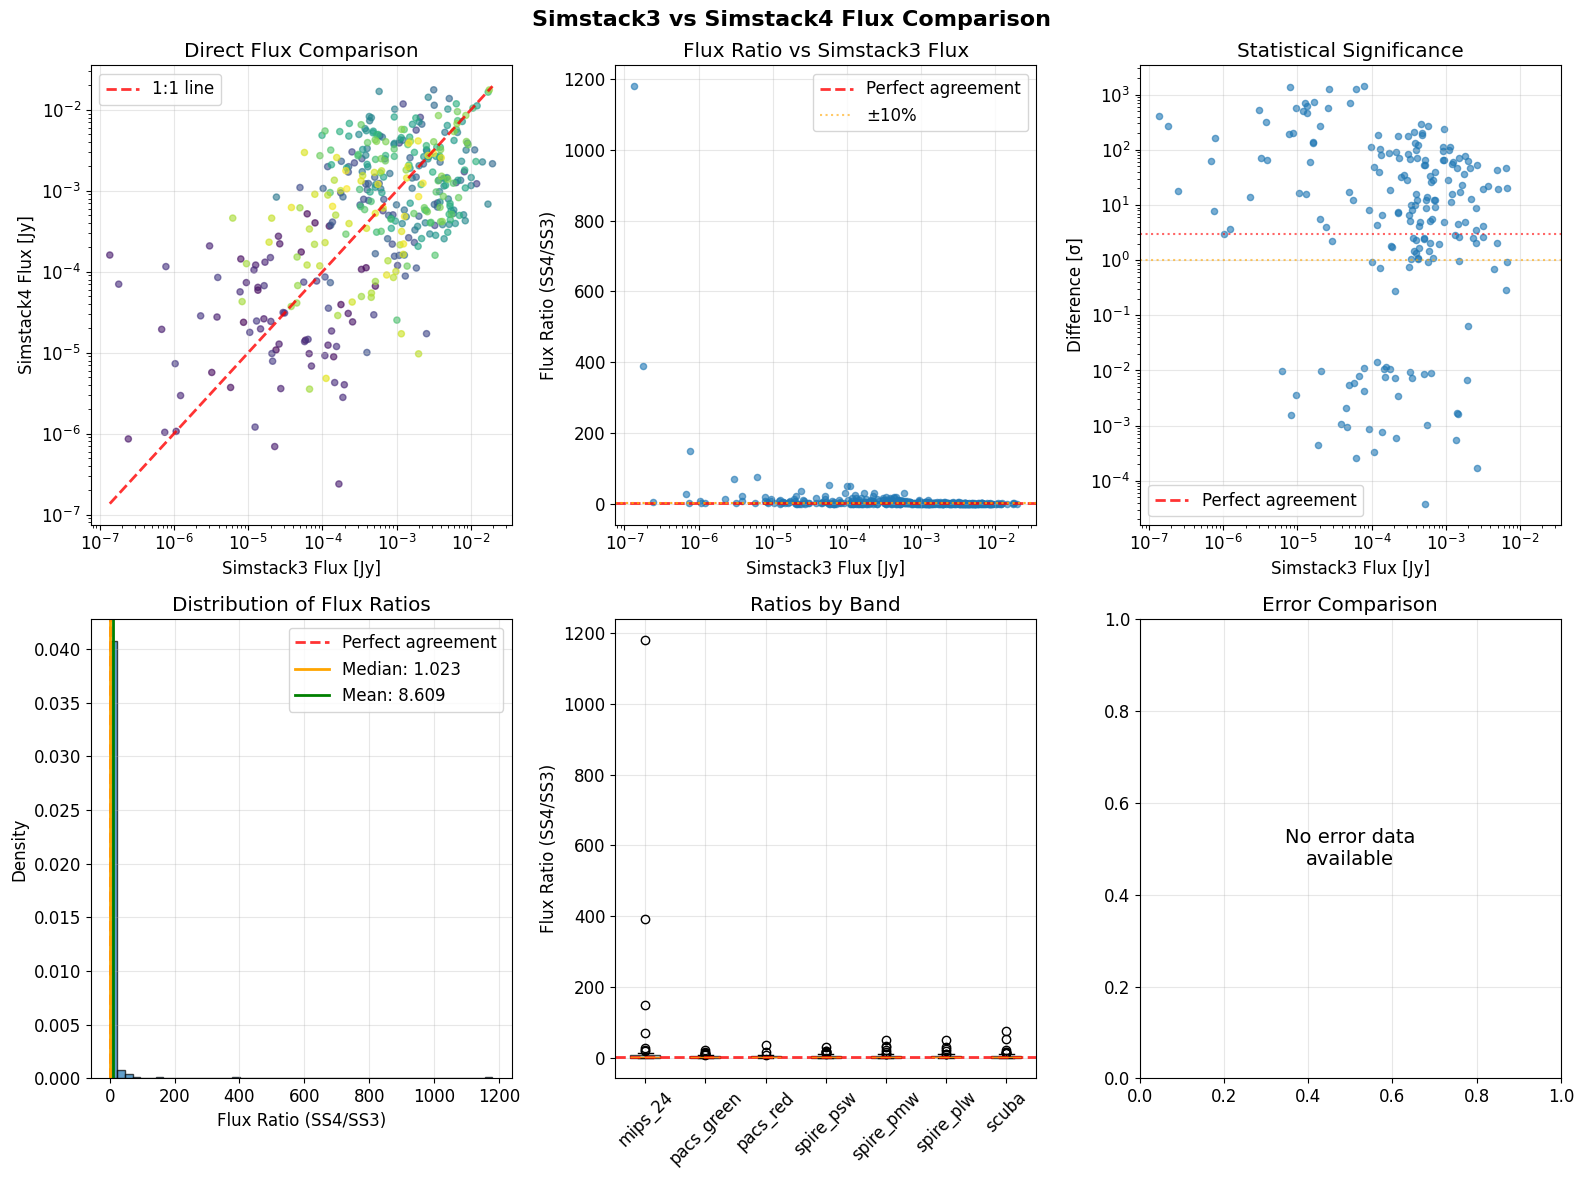

=== DETAILED BAND ANALYSIS ===

🔍 BAND: mips_24 (Unknownμm)
   Comparisons: 68
   Ratio statistics:
     Mean: 29.6347 ± 150.3954
     Median: 1.3351
     Range: 0.0014 - 1180.2334
   Agreement: 4/68 within 10%, 4/68 within 20%
   Statistical: RMS = 527.71σ
   Trend: correlation(SS3_flux, ratio) = -0.130
   ⚠️  63 outliers (>30% difference):
      redshift_0.01_0.5__stellar_mas...: ratio = 2.744
      redshift_0.01_0.5__stellar_mas...: ratio = 0.456
      redshift_0.01_0.5__stellar_mas...: ratio = 3.382

🔍 BAND: pacs_green (Unknownμm)
   Comparisons: 55
   Ratio statistics:
     Mean: 3.2163 ± 4.6695
     Median: 0.9322
     Range: 0.0068 - 22.0071
   Agreement: 1/55 within 10%, 4/55 within 20%
   Statistical: RMS = 18.62σ
   Trend: correlation(SS3_flux, ratio) = -0.309
   ⚠️  50 outliers (>30% difference):
      redshift_0.01_0.5__stellar_mas...: ratio = 0.060
      redshift_0.01_0.5__stellar_mas...: ratio = 3.588
      redshift_0.01_0.5__stellar_mas...: ratio = 0.199

🔍 BAND: pacs_re

In [27]:
# ============================================================================
# CREATE BAND AND POPULATION MAPPINGS
# ============================================================================

def create_band_mapping(ss4_data, ss3_data, simstack4_config=None):
    """Create mapping between band names in both datasets"""
    ss4_bands = ss4_data['bands']
    ss3_bands = ss3_data['bands']
    
    print(f"Simstack4 bands: {ss4_bands}")
    print(f"Simstack3 bands: {ss3_bands}")
    
    # Try to get wavelengths from simstack4 config
    ss4_wavelengths = {}
    if simstack4_config and 'maps' in simstack4_config:
        for band, config in simstack4_config['maps'].items():
            if 'wavelength' in config:
                ss4_wavelengths[band] = config['wavelength']
    
    if ss4_wavelengths:
        print(f"Simstack4 wavelengths: {ss4_wavelengths}")
    
    # Create mapping
    mapping = {}
    
    if len(ss4_bands) == len(ss3_bands):
        # Same number of bands - try order-based mapping first
        mapping = dict(zip(ss4_bands, ss3_bands))
        print("Using order-based band mapping")
    else:
        # Different numbers - try name-based matching
        for ss4_band in ss4_bands:
            best_match = None
            for ss3_band in ss3_bands:
                # Check for name similarity
                if (ss4_band.lower() in ss3_band.lower() or 
                    ss3_band.lower() in ss4_band.lower()):
                    best_match = ss3_band
                    break
            
            if best_match:
                mapping[ss4_band] = best_match
            elif len(mapping) < len(ss3_bands):
                # Fallback to order
                mapping[ss4_band] = ss3_bands[len(mapping)]
        
        print("Using name/order-based band mapping")
    
    print(f"Band mapping: {mapping}")
    return mapping

def create_population_mapping(ss4_data, ss3_data):
    """Create mapping between population indices"""
    ss4_labels = ss4_data['population_labels']
    ss3_labels = ss3_data['population_labels']
    
    print(f"\nPopulation mapping:")
    print(f"Simstack4 populations: {len(ss4_labels)}")
    print(f"Simstack3 populations: {len(ss3_labels)}")
    
    mapping = {}
    
    # Try exact string matching
    for i, ss4_label in enumerate(ss4_labels):
        for j, ss3_label in enumerate(ss3_labels):
            if ss4_label == ss3_label:
                mapping[i] = j
                break
    
    print(f"Exact matches: {len(mapping)}")
    
    # If few exact matches, try partial matching
    if len(mapping) < min(len(ss4_labels), len(ss3_labels)) * 0.5:
        mapping = {}  # Reset
        
        for i, ss4_label in enumerate(ss4_labels):
            best_match = None
            best_score = 0
            
            for j, ss3_label in enumerate(ss3_labels):
                # Simple similarity score
                ss4_clean = ss4_label.replace('_', '').replace('-', '').lower()
                ss3_clean = ss3_label.replace('_', '').replace('-', '').lower()
                
                # Check for substring matches
                if ss4_clean in ss3_clean or ss3_clean in ss4_clean:
                    score = min(len(ss4_clean), len(ss3_clean)) / max(len(ss4_clean), len(ss3_clean))
                    if score > best_score:
                        best_score = score
                        best_match = j
            
            if best_match is not None:
                mapping[i] = best_match
        
        print(f"Partial matches: {len(mapping)}")
    
    # Fallback to order-based mapping
    if len(mapping) < min(len(ss4_labels), len(ss3_labels)) * 0.3:
        min_len = min(len(ss4_labels), len(ss3_labels))
        mapping = {i: i for i in range(min_len)}
        print(f"Using order-based mapping: {len(mapping)} pairs")
    
    # Show some examples
    print("\nExample mappings:")
    for i, (ss4_idx, ss3_idx) in enumerate(list(mapping.items())[:5]):
        print(f"  {ss4_labels[ss4_idx]} <-> {ss3_labels[ss3_idx]}")
    
    return mapping

# Create mappings if both datasets are available
if ss4_standard is not None and ss3_standard is not None:
    # Get simstack4 config for wavelength info
    ss4_config = simstack4_data.get('config', {})
    
    band_mapping = create_band_mapping(ss4_standard, ss3_standard, ss4_config)
    population_mapping = create_population_mapping(ss4_standard, ss3_standard)
    
    print(f"\n✅ Created mappings:")
    print(f"  Band pairs: {len(band_mapping)}")
    print(f"  Population pairs: {len(population_mapping)}")
else:
    print("❌ Cannot create mappings - missing data")
    band_mapping = {}
    population_mapping = {}

# ============================================================================
# CREATE COMPARISON TABLE
# ============================================================================

def create_comparison_table(ss4_data, ss3_data, band_mapping, pop_mapping):
    """Create detailed comparison table"""
    comparison_data = []
    
    for ss4_band, ss3_band in band_mapping.items():
        if ss3_band not in ss3_data['flux_densities']:
            print(f"Warning: {ss3_band} not found in simstack3 flux data")
            continue
        
        ss4_fluxes = ss4_data['flux_densities'][ss4_band]
        ss4_errors = ss4_data['flux_errors'].get(ss4_band, [0] * len(ss4_fluxes))
        
        ss3_fluxes = ss3_data['flux_densities'][ss3_band]
        ss3_errors = ss3_data['flux_errors'].get(ss3_band, [0] * len(ss3_fluxes))
        
        for ss4_idx, ss3_idx in pop_mapping.items():
            if ss4_idx >= len(ss4_fluxes) or ss3_idx >= len(ss3_fluxes):
                continue
                
            flux_ss4 = ss4_fluxes[ss4_idx]
            flux_ss3 = ss3_fluxes[ss3_idx]
            error_ss4 = ss4_errors[ss4_idx] if ss4_idx < len(ss4_errors) else 0.0
            error_ss3 = ss3_errors[ss3_idx] if ss3_idx < len(ss3_errors) else 0.0
            
            # Calculate comparison metrics
            flux_ratio = flux_ss4 / flux_ss3 if flux_ss3 != 0 else np.nan
            
            combined_error = np.sqrt(error_ss4**2 + error_ss3**2)
            flux_diff_sigma = (flux_ss4 - flux_ss3) / combined_error if combined_error > 0 else np.nan
            
            comparison_data.append({
                'band_ss4': ss4_band,
                'band_ss3': ss3_band,
                'population_ss4': ss4_data['population_labels'][ss4_idx],
                'population_ss3': ss3_data['population_labels'][ss3_idx],
                'pop_idx_ss4': ss4_idx,
                'pop_idx_ss3': ss3_idx,
                'flux_ss4': flux_ss4,
                'flux_ss3': flux_ss3,
                'error_ss4': error_ss4,
                'error_ss3': error_ss3,
                'flux_ratio': flux_ratio,
                'flux_diff_sigma': flux_diff_sigma,
                'abs_diff': abs(flux_ss4 - flux_ss3),
                'rel_diff': abs(flux_ratio - 1) if not np.isnan(flux_ratio) else np.nan
            })
    
    return pd.DataFrame(comparison_data)

# Create comparison table
if ss4_standard is not None and ss3_standard is not None and band_mapping and population_mapping:
    comparison_df = create_comparison_table(ss4_standard, ss3_standard, band_mapping, population_mapping)
    
    print(f"✅ Comparison table created with {len(comparison_df)} entries")
    print(f"Bands compared: {comparison_df['band_ss4'].nunique()}")
    print(f"Populations compared: {comparison_df['pop_idx_ss4'].nunique()}")
    
    # Show sample data
    print("\nSample comparison data:")
    print(comparison_df.head(10))
else:
    comparison_df = pd.DataFrame()
    print("❌ Cannot create comparison table")

# ============================================================================
# STATISTICAL SUMMARY
# ============================================================================

def print_comparison_summary(df):
    """Print detailed statistical summary"""
    if df.empty:
        print("No comparison data available")
        return
    
    print("=== FLUX COMPARISON SUMMARY ===")
    print(f"Total comparisons: {len(df)}")
    
    # Filter valid data (positive fluxes, finite ratios)
    valid_mask = (
        (df['flux_ss4'] > 0) & 
        (df['flux_ss3'] > 0) &
        np.isfinite(df['flux_ratio'])
    )
    valid_data = df[valid_mask]
    
    if valid_data.empty:
        print("❌ No valid data for statistics")
        return
    
    print(f"Valid comparisons: {len(valid_data)} ({100*len(valid_data)/len(df):.1f}%)")
    print()
    
    # Overall flux statistics
    print("FLUX STATISTICS:")
    print(f"  Simstack4 flux range: {valid_data['flux_ss4'].min():.2e} to {valid_data['flux_ss4'].max():.2e} Jy")
    print(f"  Simstack3 flux range: {valid_data['flux_ss3'].min():.2e} to {valid_data['flux_ss3'].max():.2e} Jy")
    print()
    
    # Ratio statistics
    ratios = valid_data['flux_ratio']
    print("FLUX RATIO STATISTICS (SS4/SS3):")
    print(f"  Mean: {ratios.mean():.4f}")
    print(f"  Median: {ratios.median():.4f}")
    print(f"  Std Dev: {ratios.std():.4f}")
    print(f"  Min: {ratios.min():.4f}")
    print(f"  Max: {ratios.max():.4f}")
    print(f"  25th percentile: {ratios.quantile(0.25):.4f}")
    print(f"  75th percentile: {ratios.quantile(0.75):.4f}")
    print()
    
    # Agreement levels
    agreement_levels = [0.05, 0.10, 0.20, 0.50]
    print("AGREEMENT LEVELS:")
    for level in agreement_levels:
        within_level = np.sum(np.abs(ratios - 1) < level)
        print(f"  Within {level*100:4.0f}%: {within_level:4d}/{len(valid_data)} ({100*within_level/len(valid_data):5.1f}%)")
    print()
    
    # Statistical significance
    valid_sigma = valid_data[np.isfinite(valid_data['flux_diff_sigma'])]
    if not valid_sigma.empty:
        sigma_stats = valid_sigma['flux_diff_sigma']
        print("STATISTICAL SIGNIFICANCE:")
        print(f"  Mean difference: {sigma_stats.mean():.2f} σ")
        print(f"  RMS difference: {np.sqrt(np.mean(sigma_stats**2)):.2f} σ")
        
        sig_levels = [1, 2, 3, 5]
        for sig in sig_levels:
            significant = np.sum(np.abs(sigma_stats) > sig)
            print(f"  > {sig}σ difference: {significant:4d}/{len(valid_sigma)} ({100*significant/len(valid_sigma):5.1f}%)")
        print()
    
    # Band-by-band summary
    print("BAND-BY-BAND SUMMARY:")
    for band in valid_data['band_ss4'].unique():
        band_data = valid_data[valid_data['band_ss4'] == band]
        band_ratios = band_data['flux_ratio']
        
        # Get wavelength if available
        wavelength_info = ""
        if 'config' in simstack4_data and 'maps' in simstack4_data['config']:
            maps = simstack4_data['config']['maps']
            if band in maps and 'wavelength' in maps[band]:
                wavelength_info = f" ({maps[band]['wavelength']}μm)"
        
        print(f"  {band}{wavelength_info}:")
        print(f"    {len(band_data):3d} points, median ratio = {band_ratios.median():.4f}")
        print(f"    Range: {band_ratios.min():.4f} - {band_ratios.max():.4f}")
    print()
    
    # Outliers
    outlier_threshold = 0.5  # 50% difference
    outliers = valid_data[np.abs(valid_data['flux_ratio'] - 1) > outlier_threshold]
    
    if not outliers.empty:
        print(f"LARGE DISCREPANCIES (>{outlier_threshold*100:.0f}% difference): {len(outliers)}")
        for _, row in outliers.head(10).iterrows():
            pop_name = row['population_ss4'][:40] + "..." if len(row['population_ss4']) > 40 else row['population_ss4']
            print(f"  {row['band_ss4']:12s} {pop_name:40s}: ratio = {row['flux_ratio']:.3f}")
        if len(outliers) > 10:
            print(f"  ... and {len(outliers) - 10} more")
    else:
        print("✅ No large discrepancies found!")

# Print summary
if not comparison_df.empty:
    print_comparison_summary(comparison_df)
else:
    print("No comparison data to summarize")

# ============================================================================
# VISUALIZATION: FLUX COMPARISON PLOTS
# ============================================================================

def plot_flux_comparison(df, log_scale=True, figsize=(16, 12)):
    """Create comprehensive flux comparison plots"""
    if df.empty:
        print("No data to plot")
        return
    
    # Filter valid data
    valid_data = df[
        (df['flux_ss4'] > 0) & 
        (df['flux_ss3'] > 0) &
        np.isfinite(df['flux_ratio'])
    ].copy()
    
    if valid_data.empty:
        print("No valid data to plot")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle('Simstack3 vs Simstack4 Flux Comparison', fontsize=16, fontweight='bold')
    
    # Plot 1: Direct comparison scatter
    ax1 = axes[0, 0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(valid_data)))
    scatter = ax1.scatter(valid_data['flux_ss3'], valid_data['flux_ss4'], 
                        c=colors, alpha=0.6, s=20)
    
    # 1:1 line
    min_flux = min(valid_data['flux_ss3'].min(), valid_data['flux_ss4'].min())
    max_flux = max(valid_data['flux_ss3'].max(), valid_data['flux_ss4'].max())
    ax1.plot([min_flux, max_flux], [min_flux, max_flux], 'r--', alpha=0.8, linewidth=2, label='1:1 line')
    
    ax1.set_xlabel('Simstack3 Flux [Jy]')
    ax1.set_ylabel('Simstack4 Flux [Jy]')
    ax1.set_title('Direct Flux Comparison')
    ax1.legend()
    
    if log_scale and min_flux > 0:
        ax1.set_xscale('log')
        ax1.set_yscale('log')
    
    # Plot 2: Flux ratios vs SS3 flux
    ax2 = axes[0, 1]
    ax2.scatter(valid_data['flux_ss3'], valid_data['flux_ratio'], alpha=0.6, s=20)
    ax2.axhline(y=1, color='r', linestyle='--', alpha=0.8, linewidth=2, label='Perfect agreement')
    ax2.axhline(y=1.1, color='orange', linestyle=':', alpha=0.6, label='±10%')
    ax2.axhline(y=0.9, color='orange', linestyle=':', alpha=0.6)
    
    ax2.set_xlabel('Simstack3 Flux [Jy]')
    ax2.set_ylabel('Flux Ratio (SS4/SS3)')
    ax2.set_title('Flux Ratio vs Simstack3 Flux')
    ax2.legend()
    
    if log_scale and valid_data['flux_ss3'].min() > 0:
        ax2.set_xscale('log')
    
    # Plot 3: Statistical significance
    ax3 = axes[0, 2]
    valid_sigma = valid_data[np.isfinite(valid_data['flux_diff_sigma'])]
    if not valid_sigma.empty:
        ax3.scatter(valid_sigma['flux_ss3'], valid_sigma['flux_diff_sigma'], alpha=0.6, s=20)
        ax3.axhline(y=0, color='r', linestyle='--', alpha=0.8, linewidth=2, label='Perfect agreement')
        for sig in [1, -1, 3, -3]:
            color = 'orange' if abs(sig) == 1 else 'red'
            ax3.axhline(y=sig, color=color, linestyle=':', alpha=0.6)
        
        ax3.set_xlabel('Simstack3 Flux [Jy]')
        ax3.set_ylabel('Difference [σ]')
        ax3.set_title('Statistical Significance')
        ax3.legend()
        
        if log_scale and valid_sigma['flux_ss3'].min() > 0:
            ax3.set_xscale('log')
            ax3.set_yscale('log')
    
    # Plot 4: Histogram of ratios
    ax4 = axes[1, 0]
    ratios = valid_data['flux_ratio']
    ax4.hist(ratios, bins=50, alpha=0.7, edgecolor='black', density=True)
    ax4.axvline(x=1, color='r', linestyle='--', alpha=0.8, linewidth=2, label='Perfect agreement')
    ax4.axvline(x=ratios.median(), color='orange', linestyle='-', linewidth=2, 
                label=f'Median: {ratios.median():.3f}')
    ax4.axvline(x=ratios.mean(), color='green', linestyle='-', linewidth=2, 
                label=f'Mean: {ratios.mean():.3f}')
    
    ax4.set_xlabel('Flux Ratio (SS4/SS3)')
    ax4.set_ylabel('Density')
    ax4.set_title('Distribution of Flux Ratios')
    ax4.legend()
    
    # Plot 5: Band-by-band comparison
    ax5 = axes[1, 1]
    bands = valid_data['band_ss4'].unique()
    band_ratios = []
    band_labels = []
    
    for band in bands:
        band_data = valid_data[valid_data['band_ss4'] == band]
        if len(band_data) > 0:
            band_ratios.append(band_data['flux_ratio'].values)
            
            # Try to get wavelength for label
            label = band
            if 'config' in simstack4_data and 'maps' in simstack4_data['config']:
                maps = simstack4_data['config']['maps']
                if band in maps and 'wavelength' in maps[band]:
                    label = f"{band}\n({maps[band]['wavelength']}μm)"
            
            band_labels.append(label)
    
    if band_ratios:
        bp = ax5.boxplot(band_ratios, labels=band_labels, patch_artist=True)
        ax5.axhline(y=1, color='r', linestyle='--', alpha=0.8, linewidth=2)
        
        # Color boxes
        colors = plt.cm.Set3(np.linspace(0, 1, len(bp['boxes'])))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax5.set_ylabel('Flux Ratio (SS4/SS3)')
        ax5.set_title('Ratios by Band')
        ax5.tick_params(axis='x', rotation=45)
    
    # Plot 6: Error comparison
    ax6 = axes[1, 2]
    valid_errors = valid_data[(valid_data['error_ss4'] > 0) & (valid_data['error_ss3'] > 0)]
    if not valid_errors.empty:
        ax6.scatter(valid_errors['error_ss3'], valid_errors['error_ss4'], alpha=0.6, s=20)
        
        min_err = min(valid_errors['error_ss3'].min(), valid_errors['error_ss4'].min())
        max_err = max(valid_errors['error_ss3'].max(), valid_errors['error_ss4'].max())
        ax6.plot([min_err, max_err], [min_err, max_err], 'r--', alpha=0.8, linewidth=2, label='1:1 line')
        
        ax6.set_xlabel('Simstack3 Error [Jy]')
        ax6.set_ylabel('Simstack4 Error [Jy]')
        ax6.set_title('Error Comparison')
        ax6.legend()
        
        if log_scale and min_err > 0:
            ax6.set_xscale('log')
            ax6.set_yscale('log')
    else:
        ax6.text(0.5, 0.5, 'No error data\navailable', ha='center', va='center', 
                transform=ax6.transAxes, fontsize=14)
        ax6.set_title('Error Comparison')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Create plots
if not comparison_df.empty:
    print("Creating flux comparison plots...")
    fig = plot_flux_comparison(comparison_df, log_scale=True)
else:
    print("No data available for plotting")

# ============================================================================
# DETAILED BAND ANALYSIS
# ============================================================================

def analyze_band_details(df):
    """Detailed analysis of each band"""
    if df.empty:
        return
    
    valid_data = df[
        (df['flux_ss4'] > 0) & 
        (df['flux_ss3'] > 0) &
        np.isfinite(df['flux_ratio'])
    ]
    
    print("=== DETAILED BAND ANALYSIS ===")
    
    # Get wavelength info if available
    wavelength_map = {}
    if 'config' in simstack4_data and 'maps' in simstack4_data['config']:
        for band, config in simstack4_data['config']['maps'].items():
            if 'wavelength' in config:
                wavelength_map[band] = config['wavelength']
    
    for band in sorted(valid_data['band_ss4'].unique()):
        band_data = valid_data[valid_data['band_ss4'] == band]
        
        if len(band_data) == 0:
            continue
        
        wavelength = wavelength_map.get(band, 'Unknown')
        print(f"\n🔍 BAND: {band} ({wavelength}μm)")
        print(f"   Comparisons: {len(band_data)}")
        
        ratios = band_data['flux_ratio']
        print(f"   Ratio statistics:")
        print(f"     Mean: {ratios.mean():.4f} ± {ratios.std():.4f}")
        print(f"     Median: {ratios.median():.4f}")
        print(f"     Range: {ratios.min():.4f} - {ratios.max():.4f}")
        
        # Agreement levels
        within_10pct = np.sum(np.abs(ratios - 1) < 0.1)
        within_20pct = np.sum(np.abs(ratios - 1) < 0.2)
        print(f"   Agreement: {within_10pct}/{len(band_data)} within 10%, {within_20pct}/{len(band_data)} within 20%")
        
        # Statistical significance
        valid_sigma = band_data[np.isfinite(band_data['flux_diff_sigma'])]
        if not valid_sigma.empty:
            sigma_vals = valid_sigma['flux_diff_sigma']
            rms_sigma = np.sqrt(np.mean(sigma_vals**2))
            print(f"   Statistical: RMS = {rms_sigma:.2f}σ")
        
        # Check for systematic trends
        flux_corr = np.corrcoef(band_data['flux_ss3'], band_data['flux_ratio'])[0, 1]
        if not np.isnan(flux_corr):
            print(f"   Trend: correlation(SS3_flux, ratio) = {flux_corr:.3f}")
        
        # Worst outliers
        outliers = band_data[np.abs(band_data['flux_ratio'] - 1) > 0.3]
        if len(outliers) > 0:
            print(f"   ⚠️  {len(outliers)} outliers (>30% difference):")
            for _, row in outliers.head(3).iterrows():
                pop_short = row['population_ss4'][:30] + "..." if len(row['population_ss4']) > 30 else row['population_ss4']
                print(f"      {pop_short}: ratio = {row['flux_ratio']:.3f}")

# Run detailed analysis
if not comparison_df.empty:
    analyze_band_details(comparison_df)
else:
    print("No data for detailed analysis")

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save comparison table
if not comparison_df.empty:
    # Create output filename with timestamp
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    output_file = f"simstack_comparison_{timestamp}.csv"
    comparison_df.to_csv(output_file, index=False)
    
    print(f"✅ Comparison data saved to: {output_file}")
    print(f"   Columns: {list(comparison_df.columns)}")
    print(f"   Shape: {comparison_df.shape}")
    
    # Also save a summary
    summary_file = f"simstack_summary_{timestamp}.txt"
    with open(summary_file, 'w') as f:
        f.write("Simstack3 vs Simstack4 Comparison Summary\n")
        f.write("=" * 50 + "\n\n")
        
        f.write(f"Generated: {datetime.now().isoformat()}\n")
        f.write(f"Simstack3 dir: {SIMSTACK3_DIR}\n")
        f.write(f"Simstack4 file: {SIMSTACK4_FILE}\n\n")
        
        if ss4_standard and ss3_standard:
            f.write(f"Data Summary:\n")
            f.write(f"  SS4 bands: {ss4_standard['n_bands']}, populations: {ss4_standard['n_populations']}\n")
            f.write(f"  SS3 bands: {ss3_standard['n_bands']}, populations: {ss3_standard['n_populations']}\n")
            f.write(f"  Comparisons: {len(comparison_df)}\n\n")
        
        valid_data = comparison_df[
            (comparison_df['flux_ss4'] > 0) & 
            (comparison_df['flux_ss3'] > 0) &
            np.isfinite(comparison_df['flux_ratio'])
        ]
        
        if not valid_data.empty:
            ratios = valid_data['flux_ratio']
            f.write(f"Statistical Summary:\n")
            f.write(f"  Valid comparisons: {len(valid_data)}\n")
            f.write(f"  Ratio mean: {ratios.mean():.4f}\n")
            f.write(f"  Ratio median: {ratios.median():.4f}\n")
            f.write(f"  Ratio std: {ratios.std():.4f}\n")
            
            within_10pct = np.sum(np.abs(ratios - 1) < 0.1)
            within_20pct = np.sum(np.abs(ratios - 1) < 0.2)
            f.write(f"  Within 10%: {within_10pct}/{len(valid_data)} ({100*within_10pct/len(valid_data):.1f}%)\n")
            f.write(f"  Within 20%: {within_20pct}/{len(valid_data)} ({100*within_20pct/len(valid_data):.1f}%)\n")
    
    print(f"✅ Summary saved to: {summary_file}")
else:
    print("❌ No data to save")

# ============================================================================
# QUICK ASSESSMENT
# ============================================================================

def quick_assessment(df):
    """Provide a quick go/no-go assessment"""
    if df.empty:
        print("❌ NO DATA - Cannot assess")
        return False
    
    valid_data = df[
        (df['flux_ss4'] > 0) & 
        (df['flux_ss3'] > 0) &
        np.isfinite(df['flux_ratio'])
    ]
    
    if valid_data.empty:
        print("❌ NO VALID DATA - Cannot assess")
        return False
    
    ratios = valid_data['flux_ratio']
    
    # Assessment criteria
    median_ratio = ratios.median()
    within_20pct = np.sum(np.abs(ratios - 1) < 0.2) / len(valid_data)
    within_50pct = np.sum(np.abs(ratios - 1) < 0.5) / len(valid_data)
    
    print("\n" + "=" * 50)
    print("🔍 QUICK ASSESSMENT")
    print("=" * 50)
    
    # Overall verdict
    if (abs(median_ratio - 1) < 0.1 and within_20pct > 0.8):
        verdict = "✅ EXCELLENT AGREEMENT"
        color = "🟢"
    elif (abs(median_ratio - 1) < 0.2 and within_50pct > 0.9):
        verdict = "✅ GOOD AGREEMENT"
        color = "🟡"
    elif (abs(median_ratio - 1) < 0.5 and within_50pct > 0.7):
        verdict = "⚠️  ACCEPTABLE AGREEMENT"
        color = "🟠"
    else:
        verdict = "❌ POOR AGREEMENT"
        color = "🔴"
    
    print(f"{color} {verdict}")
    print()
    print(f"📊 Key Metrics:")
    print(f"   Median ratio: {median_ratio:.3f}")
    print(f"   Within 20%: {within_20pct:.1%}")
    print(f"   Within 50%: {within_50pct:.1%}")
    print(f"   Valid points: {len(valid_data)}/{len(df)}")
    
    # Band-specific issues
    problem_bands = []
    for band in valid_data['band_ss4'].unique():
        band_data = valid_data[valid_data['band_ss4'] == band]
        band_median = band_data['flux_ratio'].median()
        if abs(band_median - 1) > 0.3:
            problem_bands.append(f"{band} (ratio: {band_median:.3f})")
    
    if problem_bands:
        print(f"\n⚠️  Problematic bands: {', '.join(problem_bands)}")
    else:
        print(f"\n✅ All bands show reasonable agreement")
    
    print("\n" + "=" * 50)
    
    return abs(median_ratio - 1) < 0.2 and within_50pct > 0.8

# Run assessment
if not comparison_df.empty:
    assessment_pass = quick_assessment(comparison_df)
    
    if assessment_pass:
        print("\n🎉 CONCLUSION: Simstack3 and Simstack4 show good agreement!")
        print("   The implementations appear to be consistent.")
    else:
        print("\n🔧 CONCLUSION: Significant differences detected.")
        print("   Further investigation needed to identify discrepancies.")
else:
    print("\n❌ Cannot perform assessment - no comparison data")

# ============================================================================
# TROUBLESHOOTING INFORMATION
# ============================================================================

def troubleshooting_info():
    """Print diagnostic information for troubleshooting"""
    print("🔧 TROUBLESHOOTING INFORMATION")
    print("=" * 40)
    
    print("\n📁 File Status:")
    print(f"  Simstack3 dir exists: {simstack3_path.exists()}")
    print(f"  Simstack4 file exists: {simstack4_path.exists()}")
    
    if simstack3_path.exists():
        pickle_files = list(simstack3_path.glob("*.pkl"))
        print(f"  Pickle files found: {len(pickle_files)}")
    
    print("\n📊 Data Status:")
    print(f"  SS3 data loaded: {simstack3_data is not None}")
    print(f"  SS4 data loaded: {simstack4_data is not None}")
    print(f"  SS3 standardized: {ss3_standard is not None}")
    print(f"  SS4 standardized: {ss4_standard is not None}")
    
    if ss3_standard and ss4_standard:
        print(f"  Band mapping: {len(band_mapping)} pairs")
        print(f"  Population mapping: {len(population_mapping)} pairs")
        print(f"  Comparison table: {len(comparison_df)} rows")
    
    print("\n🔍 Common Issues:")
    print("  1. Wrong file paths - Update SIMSTACK3_DIR and SIMSTACK4_FILE")
    print("  2. Different data structures - Check the 'Explore Data' sections")
    print("  3. No matching populations/bands - Check mapping sections")
    print("  4. Different array shapes - May need to transpose or reformat")
    
    print("\n💡 Quick Fixes:")
    print("  - Try running each cell individually to isolate issues")
    print("  - Check the 'Explore Data' outputs for structure hints")
    print("  - Modify the standardization functions if needed")
    print("  - Contact the simstack developers if structure is unclear")

# Run troubleshooting
troubleshooting_info()

print("\n" + "="*60)
print("🎯 ANALYSIS COMPLETE!")
print("="*60)
print("Next steps:")
print("1. Review the assessment results above")
print("2. Check saved files for detailed comparison data")
print("3. If agreement is good, extend to L_IR and T_dust comparison")
print("4. If issues found, investigate specific bands/populations")
print("="*60)

    

Running population label diagnosis...
=== POPULATION LABEL DIAGNOSIS ===

First 5 population pairs:
1. SS3: redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0
   SS4: redshift_0.01_0.5__stellar_mass_8.5_9.5__split_0

2. SS3: redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_1
   SS4: redshift_0.01_0.5__stellar_mass_8.5_9.5__split_1

3. SS3: redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0
   SS4: redshift_0.01_0.5__stellar_mass_9.5_10.0__split_0

4. SS3: redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_1
   SS4: redshift_0.01_0.5__stellar_mass_9.5_10.0__split_1

5. SS3: redshift_0p01_0p5__stellar_mass_10p0_10p5__split_params_0
   SS4: redshift_0.01_0.5__stellar_mass_10.0_10.5__split_0

Star-forming populations:
  SS4 (split_0): 385
  SS3 (split_params_0): 364
Quiescent populations:
  SS4 (split_1): 364
  SS3 (split_params_1): 385

Unique SS4 populations: 108
Unique SS3 populations: 108

Creating fixed SED grid...
Found 385 star-forming galaxy data points
Sample S

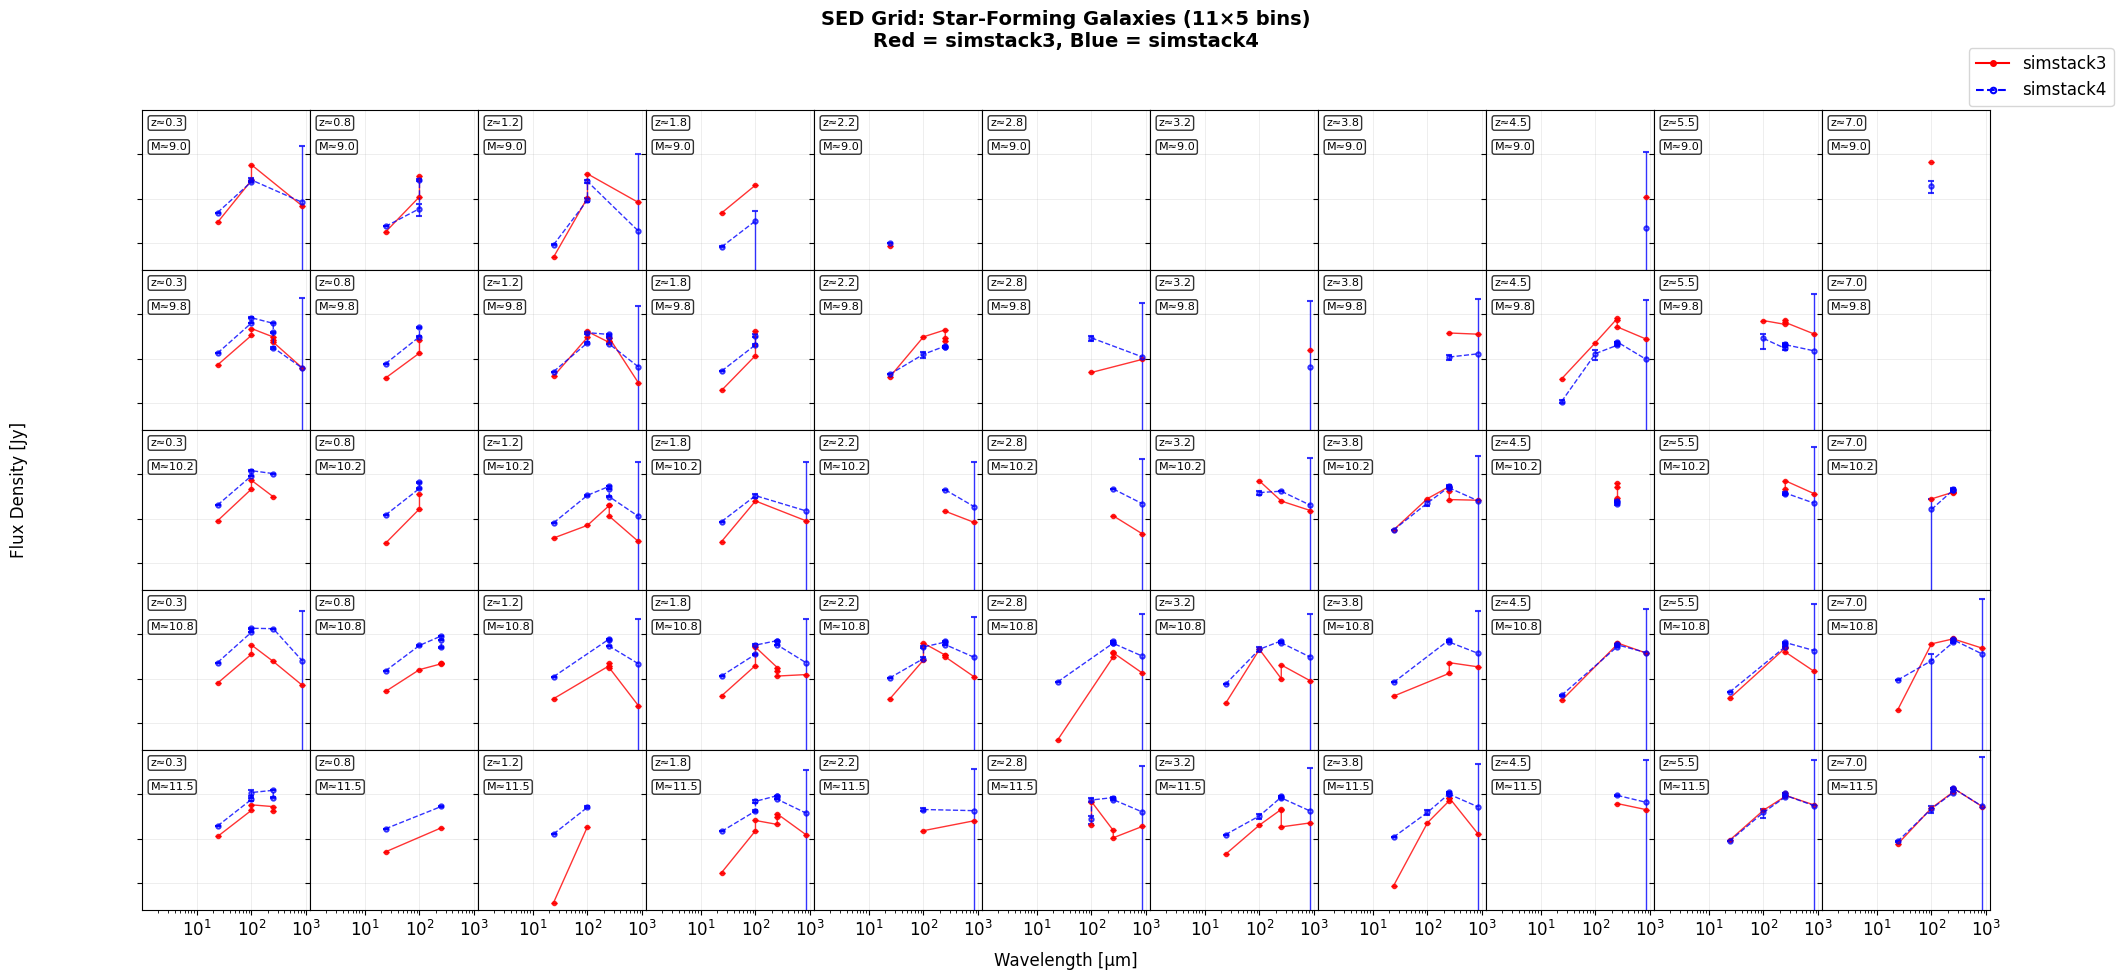

In [28]:
def create_fixed_sed_grid(save_path=None):
    """
    Create SED grid handling different population label formats
    simstack3: 'redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0'
    simstack4: 'redshift_0.01_0.5__stellar_mass_8.5_9.5__split_0'
    """
    
    if comparison_df.empty:
        print("No comparison data available")
        return None
    
    # Filter for star-forming galaxies (split_params_0 or split_0)
    sf_data = comparison_df[
        (comparison_df['population_ss4'].str.contains('split_0')) |
        (comparison_df['population_ss3'].str.contains('split_params_0'))
    ]
    
    if sf_data.empty:
        print("No star-forming galaxy data found")
        return None
    
    print(f"Found {len(sf_data)} star-forming galaxy data points")
    print(f"Sample SS3 label: {sf_data['population_ss3'].iloc[0]}")
    print(f"Sample SS4 label: {sf_data['population_ss4'].iloc[0]}")
    
    def parse_population_label(label, format_type):
        """Parse population label based on format"""
        parts = label.split('__')
        
        if format_type == 'ss3':
            # Format: redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0
            z_part = [p for p in parts if p.startswith('redshift_')][0]
            m_part = [p for p in parts if p.startswith('stellar_mass_')][0]
            
            z_vals = z_part.replace('redshift_', '').split('_')
            m_vals = m_part.replace('stellar_mass_', '').split('_')
            
            # Convert p to .
            z_min = float(z_vals[0].replace('p', '.'))
            z_max = float(z_vals[1].replace('p', '.'))
            m_min = float(m_vals[0].replace('p', '.'))
            m_max = float(m_vals[1].replace('p', '.'))
            
        else:  # ss4
            # Format: redshift_0.01_0.5__stellar_mass_8.5_9.5__split_0
            z_part = [p for p in parts if p.startswith('redshift_')][0]
            m_part = [p for p in parts if p.startswith('stellar_mass_')][0]
            
            z_vals = z_part.replace('redshift_', '').split('_')
            m_vals = m_part.replace('stellar_mass_', '').split('_')
            
            z_min = float(z_vals[0])
            z_max = float(z_vals[1])
            m_min = float(m_vals[0])
            m_max = float(m_vals[1])
        
        return {
            'z_min': z_min, 'z_max': z_max, 'z_mid': (z_min + z_max) / 2,
            'm_min': m_min, 'm_max': m_max, 'm_mid': (m_min + m_max) / 2
        }
    
    # Extract all unique bins
    z_bins = set()
    m_bins = set()
    
    for _, row in sf_data.iterrows():
        ss3_parsed = parse_population_label(row['population_ss3'], 'ss3')
        ss4_parsed = parse_population_label(row['population_ss4'], 'ss4')
        
        # Use SS4 bins as the reference (they seem more standard)
        z_bins.add((ss4_parsed['z_min'], ss4_parsed['z_max']))
        m_bins.add((ss4_parsed['m_min'], ss4_parsed['m_max']))
    
    # Sort bins
    z_bins = sorted(list(z_bins))
    m_bins = sorted(list(m_bins))
    
    print(f"Redshift bins ({len(z_bins)}): {z_bins}")
    print(f"Mass bins ({len(m_bins)}): {m_bins}")
    
    # Get wavelengths
    wavelengths = {}
    if 'config' in simstack4_data and 'maps' in simstack4_data['config']:
        for band, config in simstack4_data['config']['maps'].items():
            if 'wavelength' in config:
                wavelengths[band] = config['wavelength']
    
    if not wavelengths:
        # Default wavelength mapping
        band_mapping = {
            'mips_24': 24, 'pacs_green': 100, 'pacs_red': 160,
            'spire_psw': 250, 'spire_pmw': 350, 'spire_plw': 500, 'scuba': 850
        }
        
        for band in sf_data['band_ss4'].unique():
            for key, wave in band_mapping.items():
                if any(part in band.lower() for part in key.split('_')):
                    wavelengths[band] = wave
                    break
            else:
                # Fallback
                wavelengths[band] = 100 * (len(wavelengths) + 1)
    
    print(f"Wavelengths: {wavelengths}")
    
    # Create subplot grid
    n_mass = len(m_bins)
    n_redshift = len(z_bins)
    
    fig, axes = plt.subplots(n_mass, n_redshift, 
                            figsize=(2*n_redshift, 2*n_mass),
                            sharex=True, sharey=True,
                            gridspec_kw={'hspace': 0, 'wspace': 0})
    
    # Ensure axes is 2D
    if n_mass == 1 and n_redshift == 1:
        axes = np.array([[axes]])
    elif n_mass == 1:
        axes = axes.reshape(1, -1)
    elif n_redshift == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot each combination
    for i, (m_min, m_max) in enumerate(m_bins):
        for j, (z_min, z_max) in enumerate(z_bins):
            ax = axes[i, j]
            
            # Find matching rows for this bin
            matching_rows = []
            
            for _, row in sf_data.iterrows():
                ss3_parsed = parse_population_label(row['population_ss3'], 'ss3')
                ss4_parsed = parse_population_label(row['population_ss4'], 'ss4')
                
                # Check if this row matches our current bin (use SS4 as reference)
                z_match = (abs(ss4_parsed['z_min'] - z_min) < 0.01 and 
                          abs(ss4_parsed['z_max'] - z_max) < 0.01)
                m_match = (abs(ss4_parsed['m_min'] - m_min) < 0.01 and 
                          abs(ss4_parsed['m_max'] - m_max) < 0.01)
                
                if z_match and m_match:
                    matching_rows.append(row)
            
            if matching_rows:
                # Collect data for plotting
                plot_data = []
                
                for row in matching_rows:
                    band = row['band_ss4']
                    if band in wavelengths and row['flux_ss3'] > 0 and row['flux_ss4'] > 0:
                        plot_data.append({
                            'wave': wavelengths[band],
                            'flux_ss3': row['flux_ss3'],
                            'flux_ss4': row['flux_ss4'],
                            'error_ss3': row['error_ss3'],
                            'error_ss4': row['error_ss4']
                        })
                
                if plot_data:
                    # Sort by wavelength
                    plot_data = sorted(plot_data, key=lambda x: x['wave'])
                    
                    waves = [d['wave'] for d in plot_data]
                    fluxes_ss3 = [d['flux_ss3'] for d in plot_data]
                    fluxes_ss4 = [d['flux_ss4'] for d in plot_data]
                    errors_ss3 = [d['error_ss3'] for d in plot_data]
                    errors_ss4 = [d['error_ss4'] for d in plot_data]
                    
                    # Plot simstack3 (red filled)
                    ax.errorbar(waves, fluxes_ss3, yerr=errors_ss3,
                               fmt='o-', color='red', markersize=3, linewidth=1, 
                               alpha=0.8, capsize=2)
                    
                    # Plot simstack4 (blue open)
                    ax.errorbar(waves, fluxes_ss4, yerr=errors_ss4,
                               fmt='o--', color='blue', markersize=3, linewidth=1,
                               alpha=0.8, fillstyle='none', markeredgewidth=1.5, capsize=2)
                    
                    print(f"Plotted {len(plot_data)} points for z:[{z_min:.2f},{z_max:.2f}], m:[{m_min:.1f},{m_max:.1f}]")
            
            # Formatting
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3, linewidth=0.5)
            
            # Remove tick labels except edges
            if i < n_mass - 1:
                ax.set_xticklabels([])
            if j > 0:
                ax.set_yticklabels([])
            
            # Add bin info as text
            z_mid = (z_min + z_max) / 2
            m_mid = (m_min + m_max) / 2
            
            ax.text(0.05, 0.95, f'z≈{z_mid:.1f}', transform=ax.transAxes,
                   fontsize=8, va='top', ha='left',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
            ax.text(0.05, 0.80, f'M≈{m_mid:.1f}', transform=ax.transAxes,
                   fontsize=8, va='top', ha='left',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    # Add labels and title
    fig.text(0.5, 0.02, 'Wavelength [μm]', ha='center', va='bottom', fontsize=12)
    fig.text(0.02, 0.5, 'Flux Density [Jy]', ha='left', va='center', rotation=90, fontsize=12)
    
    fig.suptitle(f'SED Grid: Star-Forming Galaxies ({n_redshift}×{n_mass} bins)\n' +
                 'Red = simstack3, Blue = simstack4', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='red', linestyle='-', markersize=4,
               label='simstack3'),
        Line2D([0], [0], marker='o', color='blue', linestyle='--', markersize=4,
               label='simstack4', fillstyle='none', markeredgewidth=1.5)
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.95))
    
    plt.subplots_adjust(left=0.08, bottom=0.08, right=0.92, top=0.88, hspace=0, wspace=0)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"SED grid saved to: {save_path}")
    else:
        plt.show()
    
    return fig

# Also create a diagnostic function to check the label formats
def diagnose_population_labels():
    """Diagnose the population label formats to understand the mapping"""
    
    if comparison_df.empty:
        print("No comparison data")
        return
    
    print("=== POPULATION LABEL DIAGNOSIS ===")
    
    # Show first few examples
    print("\nFirst 5 population pairs:")
    for i in range(min(5, len(comparison_df))):
        row = comparison_df.iloc[i]
        print(f"{i+1}. SS3: {row['population_ss3']}")
        print(f"   SS4: {row['population_ss4']}")
        print()
    
    # Count star-forming vs quiescent
    ss4_sf = comparison_df['population_ss4'].str.contains('split_0').sum()
    ss4_q = comparison_df['population_ss4'].str.contains('split_1').sum()
    ss3_sf = comparison_df['population_ss3'].str.contains('split_params_0').sum()
    ss3_q = comparison_df['population_ss3'].str.contains('split_params_1').sum()
    
    print(f"Star-forming populations:")
    print(f"  SS4 (split_0): {ss4_sf}")
    print(f"  SS3 (split_params_0): {ss3_sf}")
    print(f"Quiescent populations:")
    print(f"  SS4 (split_1): {ss4_q}")
    print(f"  SS3 (split_params_1): {ss3_q}")
    
    # Show unique bin ranges
    print(f"\nUnique SS4 populations: {comparison_df['population_ss4'].nunique()}")
    print(f"Unique SS3 populations: {comparison_df['population_ss3'].nunique()}")

# Run diagnostics first
print("Running population label diagnosis...")
diagnose_population_labels()

# Create the fixed SED grid
print("\nCreating fixed SED grid...")
if not comparison_df.empty:
    sed_fig = create_fixed_sed_grid()
else:
    print("No comparison data available")

In [29]:
comparison_df.population_ss3.iloc[0]

'redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0'

In [30]:
comparison_df.population_ss4.iloc[0]

'redshift_0.01_0.5__stellar_mass_8.5_9.5__split_0'

In [31]:
import json
import numpy as np
from datetime import datetime
from pathlib import Path

def convert_simstack3_to_json(simstack3_data, output_path="simstack3_results_converted.json"):
    """
    Convert simstack3 results to simstack4 JSON format
    
    Args:
        simstack3_data: The loaded simstack3 SimstackWrapper object
        output_path: Where to save the JSON file
    """
    
    print("Converting simstack3 results to JSON format...")
    
    # Access the results dictionary
    if hasattr(simstack3_data, 'results_dict'):
        results_dict = simstack3_data.results_dict
    else:
        raise ValueError("Cannot find results_dict in simstack3 data")
    
    # Extract band results
    if 'band_results_dict' not in results_dict:
        raise ValueError("Cannot find band_results_dict in simstack3 results")
    
    band_results = results_dict['band_results_dict']
    bands = list(band_results.keys())
    
    print(f"Found bands: {bands}")
    
    # Get population labels from first band
    first_band = bands[0]
    original_population_labels = list(band_results[first_band]['stacked_flux_densities'].keys())
    
    # Convert population labels to simstack4 format
    def convert_population_label(label):
        """
        Convert simstack3 format to simstack4 format:
        - Replace 'p' with '.' in numbers
        - Change 'split_params_X' to 'split_X'
        """
        # Replace p with . in numeric parts
        converted = label
        
        # Handle patterns like '0p01', '0p5', '9p5', etc.
        import re
        # Replace Xp with X. (where X is digits)
        converted = re.sub(r'(\d+)p(\d*)', r'\1.\2', converted)
        
        # Replace split_params_ with split_
        converted = converted.replace('split_params_', 'split_')
        
        return converted
    
    population_labels = [convert_population_label(label) for label in original_population_labels]
    
    print(f"Found {len(population_labels)} populations")
    print(f"Original sample labels: {original_population_labels[:3]}")
    print(f"Converted sample labels: {population_labels[:3]}")
    
    # Initialize output structure
    output_data = {
        "flux_densities": {},
        "flux_errors": {},
        "population_labels": population_labels,
        "map_names": bands,
        "n_sources": {},
        "chi_squared": {},
        "degrees_of_freedom": {},
        "reduced_chi_squared": {},
        "execution_time": 0.0,  # Not available in simstack3
        "memory_used_gb": 0,   # Not available in simstack3
        "metadata": {
            "timestamp": datetime.now().isoformat(),
            "version": "simstack3_converted",
            "config_path": "converted_from_simstack3",
            "n_populations": len(population_labels),
            "n_maps": len(bands)
        }
    }
    
    # Extract flux densities and errors for each band
    for band in bands:
        band_data = band_results[band]
        
        # Extract flux densities
        if 'stacked_flux_densities' in band_data:
            flux_list = []
            for i, pop_label in enumerate(population_labels):
                # Use original label to access data, but store with converted label
                original_label = original_population_labels[i]
                if original_label in band_data['stacked_flux_densities']:
                    flux_value = band_data['stacked_flux_densities'][original_label]
                    
                    # Handle different data types
                    if isinstance(flux_value, (list, np.ndarray)):
                        flux_list.append(float(flux_value[0]) if len(flux_value) > 0 else 0.0)
                    else:
                        flux_list.append(float(flux_value))
                else:
                    flux_list.append(0.0)
            
            output_data["flux_densities"][band] = flux_list
        
        # Extract flux errors
        if 'stacked_flux_errors' in band_data:
            error_list = []
            for i, pop_label in enumerate(population_labels):
                # Use original label to access data
                original_label = original_population_labels[i]
                if original_label in band_data['stacked_flux_errors']:
                    error_value = band_data['stacked_flux_errors'][original_label]
                    
                    # Handle different data types
                    if isinstance(error_value, (list, np.ndarray)):
                        error_list.append(float(error_value[0]) if len(error_value) > 0 else 0.0)
                    else:
                        error_list.append(float(error_value))
                else:
                    error_list.append(0.0)
            
            output_data["flux_errors"][band] = error_list
        else:
            # Create dummy errors if not available
            output_data["flux_errors"][band] = [0.0] * len(population_labels)
        
        # Extract chi-squared if available
        if 'chi_squared' in band_data:
            chi2_value = band_data['chi_squared']
            if isinstance(chi2_value, (list, np.ndarray)):
                output_data["chi_squared"][band] = float(chi2_value[0])
            else:
                output_data["chi_squared"][band] = float(chi2_value)
        else:
            output_data["chi_squared"][band] = 0.0
        
        # Extract degrees of freedom if available
        if 'degrees_of_freedom' in band_data:
            dof_value = band_data['degrees_of_freedom']
            if isinstance(dof_value, (list, np.ndarray)):
                output_data["degrees_of_freedom"][band] = int(dof_value[0])
            else:
                output_data["degrees_of_freedom"][band] = int(dof_value)
        else:
            output_data["degrees_of_freedom"][band] = 1
        
        # Calculate reduced chi-squared
        chi2 = output_data["chi_squared"][band]
        dof = output_data["degrees_of_freedom"][band]
        if dof > 0:
            output_data["reduced_chi_squared"][band] = chi2 / dof
        else:
            output_data["reduced_chi_squared"][band] = 0.0
    
    # Extract number of sources per population if available
    if 'n_sources' in results_dict:
        n_sources_data = results_dict['n_sources']
        for i, pop_label in enumerate(population_labels):
            # Use original label to access data
            original_label = original_population_labels[i]
            if original_label in n_sources_data:
                n_sources_value = n_sources_data[original_label]
                if isinstance(n_sources_value, (list, np.ndarray)):
                    output_data["n_sources"][pop_label] = int(n_sources_value[0])
                else:
                    output_data["n_sources"][pop_label] = int(n_sources_value)
            else:
                output_data["n_sources"][pop_label] = 0
    else:
        # Try to find n_sources in band results
        for pop_label in population_labels:
            # Set dummy values
            output_data["n_sources"][pop_label] = 1000
    
    # Save to JSON file
    output_path = Path(output_path)
    
    print(f"Saving converted results to: {output_path}")
    
    # Custom JSON encoder to handle numpy types
    class NumpyEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            return super().default(obj)
    
    with open(output_path, 'w') as f:
        json.dump(output_data, f, indent=2, cls=NumpyEncoder)
    
    print(f"✅ Successfully converted simstack3 results to JSON")
    print(f"   File: {output_path}")
    print(f"   Bands: {len(bands)}")
    print(f"   Populations: {len(population_labels)}")
    
    return output_data

def explore_simstack3_structure(simstack3_data):
    """
    Explore the simstack3 data structure to help with conversion
    """
    print("=== EXPLORING SIMSTACK3 STRUCTURE FOR CONVERSION ===")
    
    if not hasattr(simstack3_data, 'results_dict'):
        print("❌ No results_dict found")
        return
    
    results_dict = simstack3_data.results_dict
    print(f"Results dict keys: {list(results_dict.keys())}")
    
    if 'band_results_dict' in results_dict:
        band_results = results_dict['band_results_dict']
        bands = list(band_results.keys())
        print(f"Bands: {bands}")
        
        # Examine first band structure
        first_band = bands[0]
        band_data = band_results[first_band]
        print(f"\nFirst band ({first_band}) keys: {list(band_data.keys())}")
        
        # Check flux data structure
        if 'stacked_flux_densities' in band_data:
            flux_data = band_data['stacked_flux_densities']
            pop_labels = list(flux_data.keys())
            print(f"\nPopulation labels ({len(pop_labels)}): {pop_labels[:5]}...")
            
            # Check sample flux value
            first_pop = pop_labels[0]
            sample_flux = flux_data[first_pop]
            print(f"Sample flux value: {sample_flux} (type: {type(sample_flux)})")
        
        # Check for other useful keys
        useful_keys = ['stacked_flux_errors', 'chi_squared', 'degrees_of_freedom', 'n_sources']
        for key in useful_keys:
            if key in band_data:
                print(f"✓ Found {key} in band data")
            else:
                print(f"✗ Missing {key} in band data")
    
    # Check for global n_sources
    if 'n_sources' in results_dict:
        print(f"✓ Found global n_sources data")
    else:
        print(f"✗ No global n_sources data")

def create_simstack3_json_with_diagnostics(simstack3_data, output_path="simstack3_converted.json"):
    """
    Complete function with diagnostics and conversion
    """
    print("🔍 Step 1: Exploring simstack3 structure...")
    explore_simstack3_structure(simstack3_data)
    
    print("\n🔄 Step 2: Converting to JSON...")
    try:
        converted_data = convert_simstack3_to_json(simstack3_data, output_path)
        
        print("\n✅ Step 3: Conversion complete!")
        print(f"   Output file: {output_path}")
        print(f"   Flux density arrays: {len(converted_data['flux_densities'])}")
        print(f"   Population labels: {len(converted_data['population_labels'])}")
        
        # Show sample data
        if converted_data['flux_densities']:
            first_band = list(converted_data['flux_densities'].keys())[0]
            sample_fluxes = converted_data['flux_densities'][first_band][:5]
            print(f"   Sample fluxes from {first_band}: {sample_fluxes}")
        
        return converted_data
        
    except Exception as e:
        print(f"❌ Conversion failed: {e}")
        import traceback
        traceback.print_exc()
        return None

# Run the conversion
if 'simstack3_data' in globals() and simstack3_data is not None:
    print("Found simstack3_data, starting conversion...")
    converted_results = create_simstack3_json_with_diagnostics(
        simstack3_data, 
        "simstack3_results_converted.json"
    )
else:
    print("❌ simstack3_data not found. Please load your simstack3 results first.")
    print("Usage example:")
    print("  # After loading simstack3 data:")
    print("  converted_results = create_simstack3_json_with_diagnostics(simstack3_data)")

Found simstack3_data, starting conversion...
🔍 Step 1: Exploring simstack3 structure...
=== EXPLORING SIMSTACK3 STRUCTURE FOR CONVERSION ===
Results dict keys: ['band_results_dict']
Bands: ['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba_850']

First band (mips_24) keys: ['stacked_flux_densities']

Population labels (108): ['redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0', 'redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_1', 'redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_0', 'redshift_0p01_0p5__stellar_mass_9p5_10p0__split_params_1', 'redshift_0p01_0p5__stellar_mass_10p0_10p5__split_params_0']...
Sample flux value: <Parameter 'redshift_0p01_0p5__stellar_mass_8p5_9p5__split_params_0', value=np.float64(8.64787490896062e-06) +/- 5.54e-07, bounds=[-inf:inf]> (type: <class 'lmfit.parameter.Parameter'>)
✗ Missing stacked_flux_errors in band data
✗ Missing chi_squared in band data
✗ Missing degrees_of_freedom in band data
✗ Missing n_